Epoch 1000/20000 - Loss D.: 0.5864729881286621, Loss G.: 1.0889629125595093
Epoch 2000/20000 - Loss D.: 0.6241132020950317, Loss G.: 0.8879213333129883
Epoch 3000/20000 - Loss D.: 0.6459651589393616, Loss G.: 0.8691322803497314
Epoch 4000/20000 - Loss D.: 0.6702109575271606, Loss G.: 0.8082035779953003
Epoch 5000/20000 - Loss D.: 0.684140682220459, Loss G.: 0.755070149898529
Epoch 6000/20000 - Loss D.: 0.6781214475631714, Loss G.: 0.7601216435432434
Epoch 7000/20000 - Loss D.: 0.7017387747764587, Loss G.: 0.7118391394615173
Epoch 8000/20000 - Loss D.: 0.6620104312896729, Loss G.: 0.7692930698394775
Epoch 9000/20000 - Loss D.: 0.649920642375946, Loss G.: 0.7890641689300537
Epoch 10000/20000 - Loss D.: 0.674125611782074, Loss G.: 0.7387232184410095
Epoch 11000/20000 - Loss D.: 0.6568953990936279, Loss G.: 0.7656324505805969
Epoch 12000/20000 - Loss D.: 0.6825598478317261, Loss G.: 0.7295385599136353
Epoch 13000/20000 - Loss D.: 0.643348217010498, Loss G.: 0.7684497833251953
Epoch 14000/2

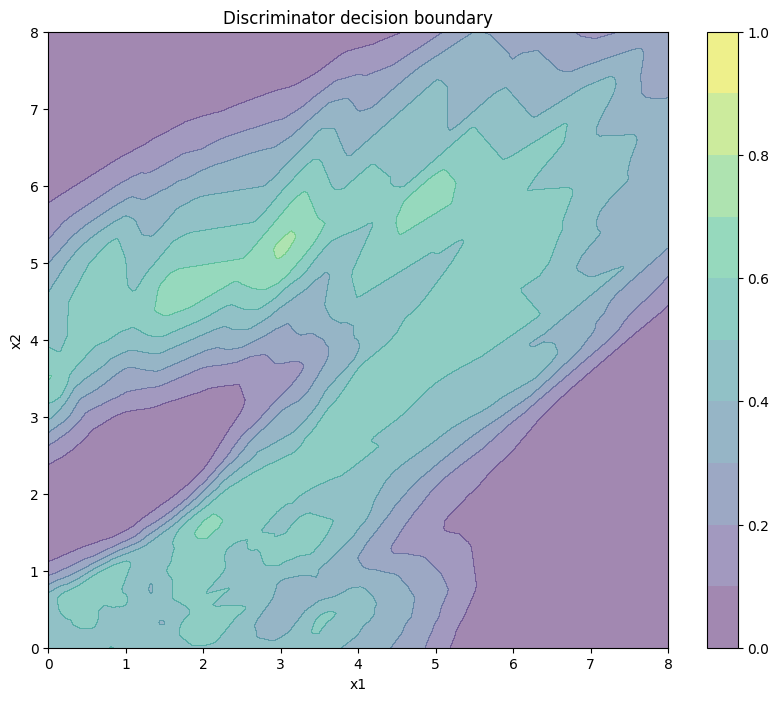

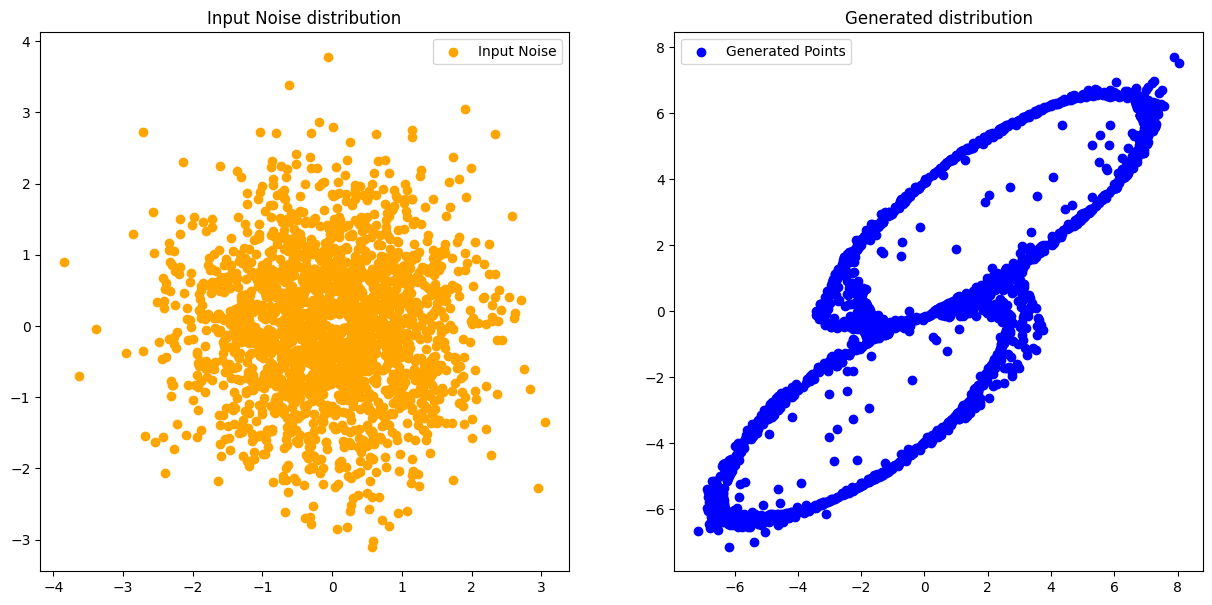

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import pickle

# Load the data
with open('hw4_p1.pkl', 'rb') as f:
    target_distribution_data = pickle.load(f)
target_distribution = torch.Tensor(target_distribution_data)

# Set device for training (GPU if available, else CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Define the generator network
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 100),
            nn.LeakyReLU(0.2),
            nn.Linear(100, 100),
            nn.LeakyReLU(0.2),
            nn.Linear(100, 2),
        )

    def forward(self, z):
        return self.model(z)

# Define the discriminator network
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 100),
            nn.LeakyReLU(0.2),
            nn.Linear(100, 100),
            nn.LeakyReLU(0.2),
            nn.Linear(100, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.model(x)

# Initialize the generator and discriminator
generator = Generator().to(device)
discriminator = Discriminator().to(device)

# Initialize the optimizers
optimizer_G = optim.Adam(generator.parameters(), lr=1e-4)
optimizer_D = optim.Adam(discriminator.parameters(), lr=1e-4)

# Binary Cross Entropy loss
criterion = nn.BCELoss()

# Training loop
num_epochs = 20000  # Adjust the number of epochs
for epoch in range(num_epochs):
    # Train the discriminator with real and fake data
    for _ in range(10):
        real_data = target_distribution[torch.randint(0, target_distribution.size(0), (2000,))].to(device)
        real_labels = torch.ones(real_data.size(0), 1, device=device)
        fake_data = generator(torch.randn(2000, 2, device=device))
        fake_labels = torch.zeros(fake_data.size(0), 1, device=device)

        optimizer_D.zero_grad()
        real_loss = criterion(discriminator(real_data), real_labels)
        fake_loss = criterion(discriminator(fake_data.detach()), fake_labels)
        d_loss = (real_loss + fake_loss) / 2
        d_loss.backward()
        optimizer_D.step()

    # Train the generator
    for _ in range(2):  # Modify range(1, 6) if you want to change generator training frequency
        optimizer_G.zero_grad()
        fake_data = generator(torch.randn(2000, 2, device=device))
        g_loss = criterion(discriminator(fake_data), real_labels)
        g_loss.backward()
        optimizer_G.step()

    # Print progress
    if (epoch+1) % 1000 == 0:
        print(f"Epoch {epoch+1}/{num_epochs} - Loss D.: {d_loss.item()}, Loss G.: {g_loss.item()}")

# Visualization after training
# Generate a 2D grid in the range of 0-8
x, y = torch.meshgrid(torch.linspace(0, 8, 200), torch.linspace(0, 8, 200))
xy = torch.stack([x.reshape(-1), y.reshape(-1)], dim=1).to(device)
with torch.no_grad():
    disc_preds = discriminator(xy).reshape(x.size()).cpu().numpy()

# Discriminator's decision boundary
plt.figure(figsize=(10, 8))
plt.contourf(x.cpu().numpy(), y.cpu().numpy(), disc_preds, alpha=0.5, levels=np.linspace(0, 1, 11))
plt.colorbar()
plt.title('Discriminator decision boundary')
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

# Sample points from the generator
with torch.no_grad():
    z = torch.randn(2000, 2).to(device)
    generated_points = generator(z).cpu().numpy()

# Input vs Generated distribution
plt.figure(figsize=(15, 7))
plt.subplot(1, 2, 1)
plt.scatter(z.cpu()[:, 0], z.cpu()[:, 1], c='orange', label='Input Noise')
plt.title('Input Noise distribution')
plt.legend()
plt.subplot(1, 2, 2)
plt.scatter(generated_points[:, 0], generated_points[:, 1], c='blue', label='Generated Points')
plt.title('Generated distribution')
plt.legend()
plt.show()